# PLACES Dataset Cleaning
Haylee Oyler
7/11/2026


In [1]:
# Load packages 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import os

# Remove max columns
pd.set_option('display.max_columns', None)


In [ ]:
# Import data
# base_dir = "/capstone/justice40"
base_dir = "~/Jobs/CCREI/network-graphs/data"

# Census tract level PLACES data
places_raw = pd.read_csv(os.path.join(base_dir,"PLACES__Local_Data_for_Better_Health,_Census_Tract_Data,_2025_release_20260711.csv"))

# Data dictionary
data_dict = pd.read_csv(os.path.join(base_dir, "PLACES_and_500_Cities__Data_Dictionary_20260711.csv"))

# GEOJSON version census tract data
places_geo_raw = gpd.read_file(os.path.join(base_dir, "PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260714.geojson"))


/var/folders/ck/21jw_cxj7j984t_wcgbyrv200000gn/T/ipykernel_83913/653982250.py:12: DtypeWarning: Columns (128,129,130,131,132,133,134) have mixed types. Specify dtype option on import or set low_memory=False.
  places_geo_raw = pd.read_csv(os.path.join(base_dir, "PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260711.geojson"))


In [3]:
places_raw.head()

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,CA,California,San Luis Obispo,6079,6079010603,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.3,NaN,NaN,3.7,4.9,"1,407","1,230",POINT (-120.8299539 35.3722416),6079010603,HLTHOUT,STROKE,CrdPrv,Stroke
1,2023,CA,California,Santa Barbara,6083,6083000501,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,3.0,NaN,NaN,2.7,3.4,"3,328","2,840",POINT (-119.7080007 34.4674371),6083000501,HLTHOUT,STROKE,CrdPrv,Stroke
2,2023,CA,California,Santa Barbara,6083,6083000806,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,2.9,NaN,NaN,2.6,3.3,"5,689","4,347",POINT (-119.6764178 34.4232883),6083000806,HLTHOUT,STROKE,CrdPrv,Stroke
3,2023,CA,California,Santa Barbara,6083,6083001002,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,27.9,NaN,NaN,22.5,33.9,"3,104","2,727",POINT (-119.7092125 34.4210021),6083001002,HLTHOUT,OBESITY,CrdPrv,Obesity
4,2023,CA,California,Santa Barbara,6083,6083001907,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,26.6,NaN,NaN,21.1,32.5,940,745,POINT (-120.0082874 34.5499261),6083001907,HLTHOUT,OBESITY,CrdPrv,Obesity


In [4]:
places_raw.shape

(14480, 24)

In [5]:
print(np.unique(places_raw['Year']))
print(np.unique(places_raw['Category']))
print(np.unique(places_raw['Short_Question_Text']))

[2022 2023]
['Disability' 'Health Outcomes' 'Health Risk Behaviors' 'Health Status'
 'Health-Related Social Needs' 'Prevention']
['All Teeth Lost' 'Annual Checkup' 'Any Disability' 'Arthritis'
 'Binge Drinking' 'COPD' 'Cancer (non-skin) or Melanoma'
 'Cholesterol Screening' 'Cognitive Disability'
 'Colorectal Cancer Screening' 'Coronary Heart Disease' 'Current Asthma'
 'Current Cigarette Smoking' 'Dental Visit' 'Depression' 'Diabetes'
 'Food Insecurity' 'Food Stamps' 'Frequent Mental Distress'
 'Frequent Physical Distress' 'General Health' 'Health Insurance'
 'Hearing Disability' 'High Blood Pressure'
 'High Blood Pressure Medication' 'High Cholesterol' 'Housing Insecurity'
 'Independent Living Disability' 'Lack of Social/Emotional Support'
 'Loneliness' 'Mammography' 'Mobility Disability' 'Obesity'
 'Physical Inactivity' 'Self-care Disability' 'Short Sleep Duration'
 'Stroke' 'Transportation Barriers' 'Utility Services Threat'
 'Vision Disability']


In [6]:
insurance = places_raw[places_raw['Short_Question_Text'] == 'Health Insurance']
insurance.shape

(362, 24)

In [7]:
insurance.head(6)

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
39,2023,CA,California,Santa Barbara,6083,6083002012,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,7.7,NaN,NaN,6.1,9.9,"3,209","2,446",POINT (-120.4436472 34.8686385),6083002012,PREVENT,ACCESS2,CrdPrv,Health Insurance
53,2023,CA,California,San Luis Obispo,6079,6079010202,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,10.9,NaN,NaN,8.5,13.6,"5,499","4,211",POINT (-120.6302235 35.5983407),6079010202,PREVENT,ACCESS2,CrdPrv,Health Insurance
72,2023,CA,California,San Luis Obispo,6079,6079012102,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,9.3,NaN,NaN,7.2,11.6,"5,482","4,459",POINT (-120.6245239 35.1222342),6079012102,PREVENT,ACCESS2,CrdPrv,Health Insurance
81,2023,CA,California,Santa Barbara,6083,6083000801,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,15.5,NaN,NaN,11.5,20.0,"4,021","3,140",POINT (-119.6856662 34.4273594),6083000801,PREVENT,ACCESS2,CrdPrv,Health Insurance
191,2023,CA,California,San Luis Obispo,6079,6079012406,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,13.4,NaN,NaN,10.3,16.6,"3,677","2,706",POINT (-120.4792384 35.0441765),6079012406,PREVENT,ACCESS2,CrdPrv,Health Insurance
311,2023,CA,California,San Luis Obispo,6079,6079010404,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,7.3,NaN,NaN,5.5,9.4,"2,219","1,915",POINT (-121.0948278 35.5748544),6079010404,PREVENT,ACCESS2,CrdPrv,Health Insurance


In [ ]:
# Read in PLACES shapefile
places_geo_raw = gpd.read_file(os.path.join(base_dir, "PLACES_Census_Tract_Data_GIS_Friendly_Format_2025_release_20260714", "geo_export_e579665d-8a19-4f5f-8e5c-a05ccfdd96f7.shp"))

# Geojson version
places_geojson = gpd.read_file(os.path.join(base_dir, "PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260714.geojson"))


,stateabbr,statedesc,countyname,countyfips,tractfips,totalpopulation,totalpop18plus,access2_crudeprev,access2_crude95ci,arthritis_crudeprev,arthritis_crude95ci,binge_crudeprev,binge_crude95ci,bphigh_crudeprev,bphigh_crude95ci,bpmed_crudeprev,bpmed_crude95ci,cancer_crudeprev,cancer_crude95ci,casthma_crudeprev,casthma_crude95ci,chd_crudeprev,chd_crude95ci,checkup_crudeprev,checkup_crude95ci,cholscreen_crudeprev,cholscreen_crude95ci,colon_screen_crudeprev,colon_screen_crude95ci,copd_crudeprev,copd_crude95ci,csmoking_crudeprev,csmoking_crude95ci,dental_crudeprev,dental_crude95ci,depression_crudeprev,depression_crude95ci,diabetes_crudeprev,diabetes_crude95ci,ghlth_crudeprev,ghlth_crude95ci,highchol_crudeprev,highchol_crude95ci,lpa_crudeprev,lpa_crude95ci,mammouse_crudeprev,mammouse_crude95ci,mhlth_crudeprev,mhlth_crude95ci,obesity_crudeprev,obesity_crude95ci,phlth_crudeprev,phlth_crude95ci,sleep_crudeprev,sleep_crude95ci,stroke_crudeprev,stroke_crude95ci,teethlost_crudeprev,teethlost_crude95ci,hearing_crudeprev,hearing_crude95ci,vision_crudeprev,vision_crude95ci,cognition_crudeprev,cognition_crude95ci,mobility_crudeprev_,mobility_crude95ci,selfcare_crudeprev,selfcare_crude95ci,indeplive_crudeprev,indeplive_crude95ci,disability_crudeprev,disability_crude95ci,loneliness_crudeprev,loneliness_crude95ci,foodstamp_crudeprev,foodstamp_crude95ci,foodinsecu_crudeprev,foodinsecu_crude95ci,housinsecu_crudeprev,housinsecu_crude95ci,shututility_crudeprev,shututility_crude95ci,lacktrpt_crudeprev,lacktrpt_crude95ci,emotionspt_crudeprev,emotionspt_crude95ci,:id,:version,:created_at,:updated_at,geometry
0,CA,California,San Luis Obispo,06079,06079010016,5643,4187,11.9,"( 9.6, 14.5)",23.4,"(20.7, 26.1)",16.6,"(13.8, 19.6)",31.6,"(28.1, 35.2)",69.8,"(66.4, 73.1)",7.7,"( 7.0, 8.5)",10.2,"( 9.0, 11.5)",6.3,"( 5.5, 7.0)",70.1,"(66.0, 73.8)",84.8,"(82.6, 86.8)",59.6,"(54.3, 64.8)",6.4,"( 5.5, 7.5)",12.8,"(10.8, 15.0)",65.0,"(61.4, 68.4)",23.1,"(19.9, 26.5)",10.7,"( 9.2, 12.3)",22.6,"(19.5, 25.8)",33.7,"(30.0, 37.6)",23.6,"(19.8, 27.7)",74.3,"(66.7, 81.1)",17.7,"(15.6, 19.8)",29.1,"(23.6, 35.2)",14.7,"(12.8, 16.6)",32.1,"(26.5, 38.0)",3.4,"( 3.0, 3.7)",11.1,"( 8.9, 13.6)",6.7,"( 5.8, 7.5)",5.7,"( 5.0, 6.3)",16.0,"(14.0, 18.2)",14.5,"(12.4, 16.6)",4.1,"( 3.6, 4.7)",8.8,"( 7.7, 10.0)",31.5,"(27.5, 35.8)",35.7,"(30.9, 40.8)",16.0,"(13.2, 19.1)",17.8,"(14.6, 21.2)",14.8,"(12.4, 17.3)",7.7,"( 6.5, 8.9)",9.4,"( 8.0, 10.9)",26.7,"(23.1, 30.8)",row-au4m_gkfi-zcd6,rv-cbvn_mz7p~bgjf,2025-12-04 10:35:19.843000+00:00,2025-12-04 10:35:19.843000+00:00,POINT (-120.79036 35.63955)
1,CA,California,San Luis Obispo,06079,06079010017,3618,2935,6.1,"( 5.0, 7.4)",27.4,"(24.4, 30.5)",16.4,"(13.8, 19.4)",34.8,"(30.9, 38.6)",73.5,"(70.1, 76.8)",10.1,"( 9.1, 11.2)",10.3,"( 9.1, 11.6)",6.8,"( 6.0, 7.6)",73.7,"(70.1, 77.2)",88.8,"(87.3, 90.2)",67.6,"(62.5, 72.5)",6.5,"( 5.6, 7.5)",12.0,"(10.0, 14.2)",66.4,"(62.9, 69.9)",23.4,"(20.0, 26.7)",10.6,"( 9.1, 12.1)",18.5,"(16.0, 21.2)",36.9,"(33.0, 41.0)",19.9,"(16.4, 23.5)",76.9,"(69.6, 83.2)",16.6,"(14.6, 18.6)",27.5,"(22.2, 33.4)",14.0,"(12.3, 15.8)",32.4,"(26.7, 38.4)",3.5,"( 3.2, 3.9)",9.9,"( 7.9, 12.2)",7.1,"( 6.3, 8.0)",4.2,"( 3.7, 4.7)",13.5,"(11.8, 15.2)",13.8,"(11.9, 15.9)",3.5,"( 3.1, 4.0)",7.5,"( 6.5, 8.4)",29.3,"(25.4, 33.3)",33.4,"(28.8, 38.1)",9.7,"( 8.0, 11.6)",10.7,"( 8.8, 12.8)",9.6,"( 8.1, 11.3)",5.2,"( 4.4, 6.0)",6.3,"( 5.5, 7.2)",24.9,"(21.4, 28.6)",row-4t9v~89px-8edc,rv-5j26_d6pm-se5c,2025-12-04 10:35:19.843000+00:00,2025-12-04 10:35:19.843000+00:00,POINT (-120.93484 35.73229)
2,CA,California,San Luis Obispo,06079,06079010101,1672,1392,6.3,"( 5.2, 7.7)",28.0,"(24.9, 31.2)",15.4,"(12.8, 18.2)",35.5,"(31.7, 39.4)",74.6,"(71.2, 77.8)",10.4,"( 9.5, 11.4)",10.2,"( 9.1, 11.5)",7.0,"( 6.2, 7.9)",74.8,"(71.3, 78.2)",89.2,"(87.7, 90.5)",69.3,"(64.4, 73.9)",6.6,"( 5.6, 7.8)",11.0,"( 9.0, 13.2)",70.6,"(67.2, 73.7)",22.7,"(19.6, 26.1)",11.1,"( 9.6, 12.8)",18.9,"(16.3, 21.8)",37.4,"(33.4, 41.5)",19.9,"(16.4, 23.6)",77.2,"(69.9, 83.

<Axes: >

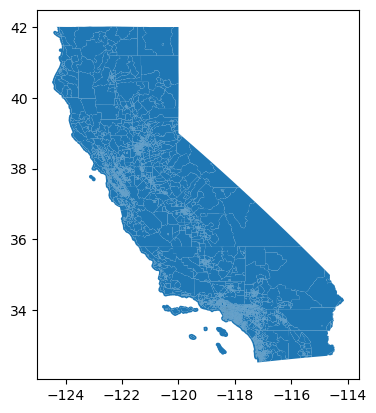

In [26]:
# Census tract boundaries
tracts = gpd.read_file(os.path.join(base_dir, "tl_2023_06_tract", "tl_2023_06_tract.shp"))
tracts.plot()

In [27]:
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,0,+37.5371513,-122.0081095,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,0,+37.5293619,-121.9931002,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,0,+34.0175004,-118.1974975,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,0,+34.0245059,-118.2142985,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,320101,06037320101,1400000US06037320101,3201.01,Census Tract 3201.01,G5020,S,680504,0,+34.2992784,-118.4326573,"POLYGON ((-118.43882 34.29911, -118.43732 34.3..."


In [21]:
type(places_geo_raw)

geopandas.geodataframe.GeoDataFrame

<Axes: >

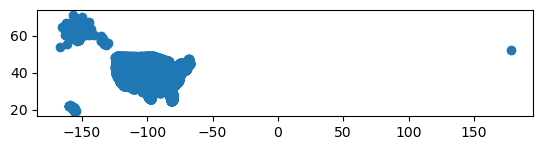

In [22]:
places_geo_raw.plot()

<Axes: >

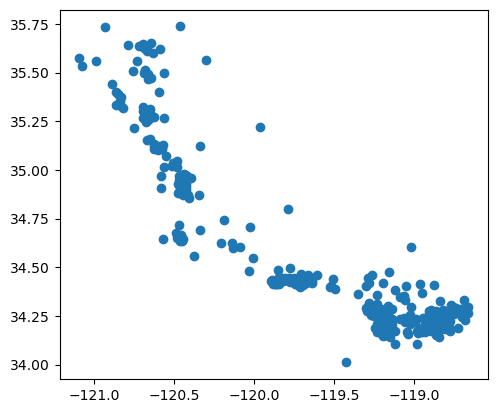

In [23]:
places_geojson.plot()

In [24]:
places_geojson.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
places_geojson.head()

,stateabbr,statedesc,countyname,countyfips,tractfips,totalpopulation,totalpop18plus,access2_crudeprev,access2_crude95ci,arthritis_crudeprev,arthritis_crude95ci,binge_crudeprev,binge_crude95ci,bphigh_crudeprev,bphigh_crude95ci,bpmed_crudeprev,bpmed_crude95ci,cancer_crudeprev,cancer_crude95ci,casthma_crudeprev,casthma_crude95ci,chd_crudeprev,chd_crude95ci,checkup_crudeprev,checkup_crude95ci,cholscreen_crudeprev,cholscreen_crude95ci,colon_screen_crudeprev,colon_screen_crude95ci,copd_crudeprev,copd_crude95ci,csmoking_crudeprev,csmoking_crude95ci,dental_crudeprev,dental_crude95ci,depression_crudeprev,depression_crude95ci,diabetes_crudeprev,diabetes_crude95ci,ghlth_crudeprev,ghlth_crude95ci,highchol_crudeprev,highchol_crude95ci,lpa_crudeprev,lpa_crude95ci,mammouse_crudeprev,mammouse_crude95ci,mhlth_crudeprev,mhlth_crude95ci,obesity_crudeprev,obesity_crude95ci,phlth_crudeprev,phlth_crude95ci,sleep_crudeprev,sleep_crude95ci,stroke_crudeprev,stroke_crude95ci,teethlost_crudeprev,teethlost_crude95ci,hearing_crudeprev,hearing_crude95ci,vision_crudeprev,vision_crude95ci,cognition_crudeprev,cognition_crude95ci,mobility_crudeprev_,mobility_crude95ci,selfcare_crudeprev,selfcare_crude95ci,indeplive_crudeprev,indeplive_crude95ci,disability_crudeprev,disability_crude95ci,loneliness_crudeprev,loneliness_crude95ci,foodstamp_crudeprev,foodstamp_crude95ci,foodinsecu_crudeprev,foodinsecu_crude95ci,housinsecu_crudeprev,housinsecu_crude95ci,shututility_crudeprev,shututility_crude95ci,lacktrpt_crudeprev,lacktrpt_crude95ci,emotionspt_crudeprev,emotionspt_crude95ci,:id,:version,:created_at,:updated_at,geometry
0,CA,California,San Luis Obispo,06079,06079010016,5643,4187,11.9,"( 9.6, 14.5)",23.4,"(20.7, 26.1)",16.6,"(13.8, 19.6)",31.6,"(28.1, 35.2)",69.8,"(66.4, 73.1)",7.7,"( 7.0, 8.5)",10.2,"( 9.0, 11.5)",6.3,"( 5.5, 7.0)",70.1,"(66.0, 73.8)",84.8,"(82.6, 86.8)",59.6,"(54.3, 64.8)",6.4,"( 5.5, 7.5)",12.8,"(10.8, 15.0)",65.0,"(61.4, 68.4)",23.1,"(19.9, 26.5)",10.7,"( 9.2, 12.3)",22.6,"(19.5, 25.8)",33.7,"(30.0, 37.6)",23.6,"(19.8, 27.7)",74.3,"(66.7, 81.1)",17.7,"(15.6, 19.8)",29.1,"(23.6, 35.2)",14.7,"(12.8, 16.6)",32.1,"(26.5, 38.0)",3.4,"( 3.0, 3.7)",11.1,"( 8.9, 13.6)",6.7,"( 5.8, 7.5)",5.7,"( 5.0, 6.3)",16.0,"(14.0, 18.2)",14.5,"(12.4, 16.6)",4.1,"( 3.6, 4.7)",8.8,"( 7.7, 10.0)",31.5,"(27.5, 35.8)",35.7,"(30.9, 40.8)",16.0,"(13.2, 19.1)",17.8,"(14.6, 21.2)",14.8,"(12.4, 17.3)",7.7,"( 6.5, 8.9)",9.4,"( 8.0, 10.9)",26.7,"(23.1, 30.8)",row-au4m_gkfi-zcd6,rv-cbvn_mz7p~bgjf,2025-12-04 10:35:19.843000+00:00,2025-12-04 10:35:19.843000+00:00,POINT (-120.79036 35.63955)
1,CA,California,San Luis Obispo,06079,06079010017,3618,2935,6.1,"( 5.0, 7.4)",27.4,"(24.4, 30.5)",16.4,"(13.8, 19.4)",34.8,"(30.9, 38.6)",73.5,"(70.1, 76.8)",10.1,"( 9.1, 11.2)",10.3,"( 9.1, 11.6)",6.8,"( 6.0, 7.6)",73.7,"(70.1, 77.2)",88.8,"(87.3, 90.2)",67.6,"(62.5, 72.5)",6.5,"( 5.6, 7.5)",12.0,"(10.0, 14.2)",66.4,"(62.9, 69.9)",23.4,"(20.0, 26.7)",10.6,"( 9.1, 12.1)",18.5,"(16.0, 21.2)",36.9,"(33.0, 41.0)",19.9,"(16.4, 23.5)",76.9,"(69.6, 83.2)",16.6,"(14.6, 18.6)",27.5,"(22.2, 33.4)",14.0,"(12.3, 15.8)",32.4,"(26.7, 38.4)",3.5,"( 3.2, 3.9)",9.9,"( 7.9, 12.2)",7.1,"( 6.3, 8.0)",4.2,"( 3.7, 4.7)",13.5,"(11.8, 15.2)",13.8,"(11.9, 15.9)",3.5,"( 3.1, 4.0)",7.5,"( 6.5, 8.4)",29.3,"(25.4, 33.3)",33.4,"(28.8, 38.1)",9.7,"( 8.0, 11.6)",10.7,"( 8.8, 12.8)",9.6,"( 8.1, 11.3)",5.2,"( 4.4, 6.0)",6.3,"( 5.5, 7.2)",24.9,"(21.4, 28.6)",row-4t9v~89px-8edc,rv-5j26_d6pm-se5c,2025-12-04 10:35:19.843000+00:00,2025-12-04 10:35:19.843000+00:00,POINT (-120.93484 35.73229)
2,CA,California,San Luis Obispo,06079,06079010101,1672,1392,6.3,"( 5.2, 7.7)",28.0,"(24.9, 31.2)",15.4,"(12.8, 18.2)",35.5,"(31.7, 39.4)",74.6,"(71.2, 77.8)",10.4,"( 9.5, 11.4)",10.2,"( 9.1, 11.5)",7.0,"( 6.2, 7.9)",74.8,"(71.3, 78.2)",89.2,"(87.7, 90.5)",69.3,"(64.4, 73.9)",6.6,"( 5.6, 7.8)",11.0,"( 9.0, 13.2)",70.6,"(67.2, 73.7)",22.7,"(19.6, 26.1)",11.1,"( 9.6, 12.8)",18.9,"(16.3, 21.8)",37.4,"(33.4, 41.5)",19.9,"(16.4, 23.6)",77.2,"(69.9, 83.

In [30]:
places_raw.head()

,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,CA,California,San Luis Obispo,6079,6079010603,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.3,NaN,NaN,3.7,4.9,"1,407","1,230",POINT (-120.8299539 35.3722416),6079010603,HLTHOUT,STROKE,CrdPrv,Stroke
1,2023,CA,California,Santa Barbara,6083,6083000501,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,3.0,NaN,NaN,2.7,3.4,"3,328","2,840",POINT (-119.7080007 34.4674371),6083000501,HLTHOUT,STROKE,CrdPrv,Stroke
2,2023,CA,California,Santa Barbara,6083,6083000806,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,2.9,NaN,NaN,2.6,3.3,"5,689","4,347",POINT (-119.6764178 34.4232883),6083000806,HLTHOUT,STROKE,CrdPrv,Stroke
3,2023,CA,California,Santa Barbara,6083,6083001002,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,27.9,NaN,NaN,22.5,33.9,"3,104","2,727",POINT (-119.7092125 34.4210021),6083001002,HLTHOUT,OBESITY,CrdPrv,Obesity
4,2023,CA,California,Santa Barbara,6083,6083001907,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,26.6,NaN,NaN,21.1,32.5,940,745,POINT (-120.0082874 34.5499261),6083001907,HLTHOUT,OBESITY,CrdPrv,Obesity


In [40]:
places_raw['LocationName'] = places_raw['LocationName'].astype('int64')
tracts['GEOID'] = tracts['GEOID'].astype('int64')

# Merge geometry df and burden df
places_complete = pd.merge(places_raw, tracts, left_on='LocationName', right_on='GEOID')

# At some point, we lost our geodataframe type. Add it back so we can map
# I think this was because of the merge
places_complete = gpd.GeoDataFrame(places_complete)

In [37]:
places_complete.shape

(14480, 38)

In [ ]:
# Save merged file
# places_complete.to_file(os.path.join(base_dir,"PLACES_tracts.geojson"),driver="GeoJSON")

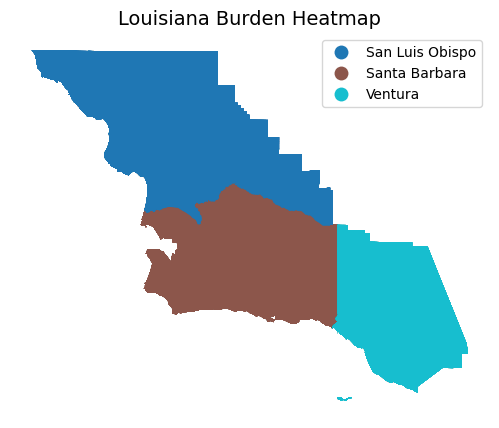

In [47]:
# Initialize figure
fig, ax = plt.subplots(figsize=(9,5))

# Remove axis for a cleaner map and set title
ax.axis('off')
ax.set_title('Louisiana Burden Heatmap',
            fontsize=14)

# Plot NY state and color by number of spills 
places_complete.plot(ax=ax,
                column='CountyName',
                # cmap='Reds',
                legend=True)
                
plt.show()